# Week 09 (Module 20) - BBO capstone driver

Round 9. W8 delivered three new bests (f6, f7, f8), all from conservative moves. Four rounds remain before the final lock-in; W12 is reserved as a dress rehearsal of the final coordinates.

**Plan:**
- **f1 -> probe (0.36, 0.44)**: the W7 signal (-0.0053 at (0.41, 0.47)) faded ~4000x toward centre in W8, so step the opposite way along the same line.
- **f2 -> AEI conservative** near the seed incumbent.
- **f3 -> EI**.
- **f4 -> micro-refine**, perturbation clamped to +/-0.01 (W8's +/-0.02 cost 0.03). Maps the narrow peak before the final-week exact re-submit.
- **f5 -> space_fill** (peak banked; exploration free).
- **f6 -> tight refine around the NEW W8 winner** (-0.254 at interior point).
- **f7 -> tight refine around the NEW W8 winner** (1.839) - the hot hand.
- **f8 -> MES** (keeps nudging the converged point up for free).


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 9
SEED = 9
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: continue the signal line away from centre.
f1_x = np.array([0.360000, 0.440000])
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="llm_probe", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0, n_data=len(bo.load(1)[1]))

def tight_refine(fid, scale, clamp=None):
    X, y, d = bo.load(fid); b = bo.bounds(fid, d)
    x_best = X[int(np.argmax(y))]
    pert = rng.normal(0, scale, size=d)
    if clamp: pert = np.clip(pert, -clamp, clamp)
    x_new = np.clip(x_best + pert, 0.0, 0.999999)
    m = bo.fit(fid)
    mean, std = m.predict(bo.to_unit(x_new.reshape(1,-1), b))
    return dict(x=x_new, u=bo.to_unit(x_new.reshape(1,-1), b).reshape(-1),
               submission=bo.format_submission(x_new), acq="tight_refine",
               mean=float(mean[0]), std=float(std[0]), incumbent_y=float(y.max()),
               n_data=len(y), model=m)

results[4] = tight_refine(4, scale=0.008, clamp=0.01)
results[6] = tight_refine(6, scale=0.02)
results[7] = tight_refine(7, scale=0.02)

GP_PLAN = {2: dict(acq="aei", xi=0.10), 3: dict(acq="ei", xi=0.01),
           5: dict(acq="space_fill"), 8: dict(acq="mes")}
for fid, plan in GP_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)

for fid in bo.FUNC_IDS:
    bo.validate_submission(results[fid]["submission"], len(results[fid]["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,source,incumbent,submission
0,f1,llm_probe,0.0000,0.360000-0.440000
1,f2,aei,0.6112,0.699851-0.047138
2,f3,ei,-0.0348,0.925193-0.999999-0.491149
3,f4,tight_refine,0.5401,0.402947-0.419269-0.342834-0.440701
4,f5,space_fill,8662.4050,0.007603-0.930329-0.997611-0.296371
5,f6,tight_refine,-0.2545,0.501950-0.357328-0.606603-0.733165-0.000000
6,f7,tight_refine,1.8390,0.000000-0.080670-0.069240-0.170319-0.382669-0...
7,f8,mes,9.9499,0.121753-0.148827-0.117863-0.213194-0.999999-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,18,0.0000,NaN,NaN,llm_probe,0.360000-0.440000
1,f2,2,18,0.6112,0.5115,0.1014,aei,0.699851-0.047138
2,f3,3,23,-0.0348,-0.0505,0.0508,ei,0.925193-0.999999-0.491149
3,f4,4,38,0.5401,0.2637,0.2217,tight_refine,0.402947-0.419269-0.342834-0.440701
4,f5,4,28,8662.4050,-184.4976,657.5885,space_fill,0.007603-0.930329-0.997611-0.296371
5,f6,5,28,-0.2545,-0.2752,0.0644,tight_refine,0.501950-0.357328-0.606603-0.733165-0.000000
6,f7,6,38,1.8390,1.7092,0.0975,tight_refine,0.000000-0.080670-0.069240-0.170319-0.382669-0...
7,f8,8,48,9.9499,9.9500,0.0013,mes,0.121753-0.148827-0.117863-0.213194-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r.get("model") or bo.fit(fid)
        r["model"] = m
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, np.atleast_2d(r["u"])).items()}
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,0.0012,0.0000,0.0000
1,f2,0.0009,0.7143,0.0244,0.0103
2,f3,0.0100,0.0512,0.3069,0.0026
3,f4,0.0103,0.7072,0.0982,0.0492
4,f5,0.0000,1130.6795,0.0000,432422.6635
5,f6,0.0132,-0.1465,0.3167,0.0041
6,f7,0.0033,1.9042,0.0759,0.0095
7,f8,0.0000,9.9525,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

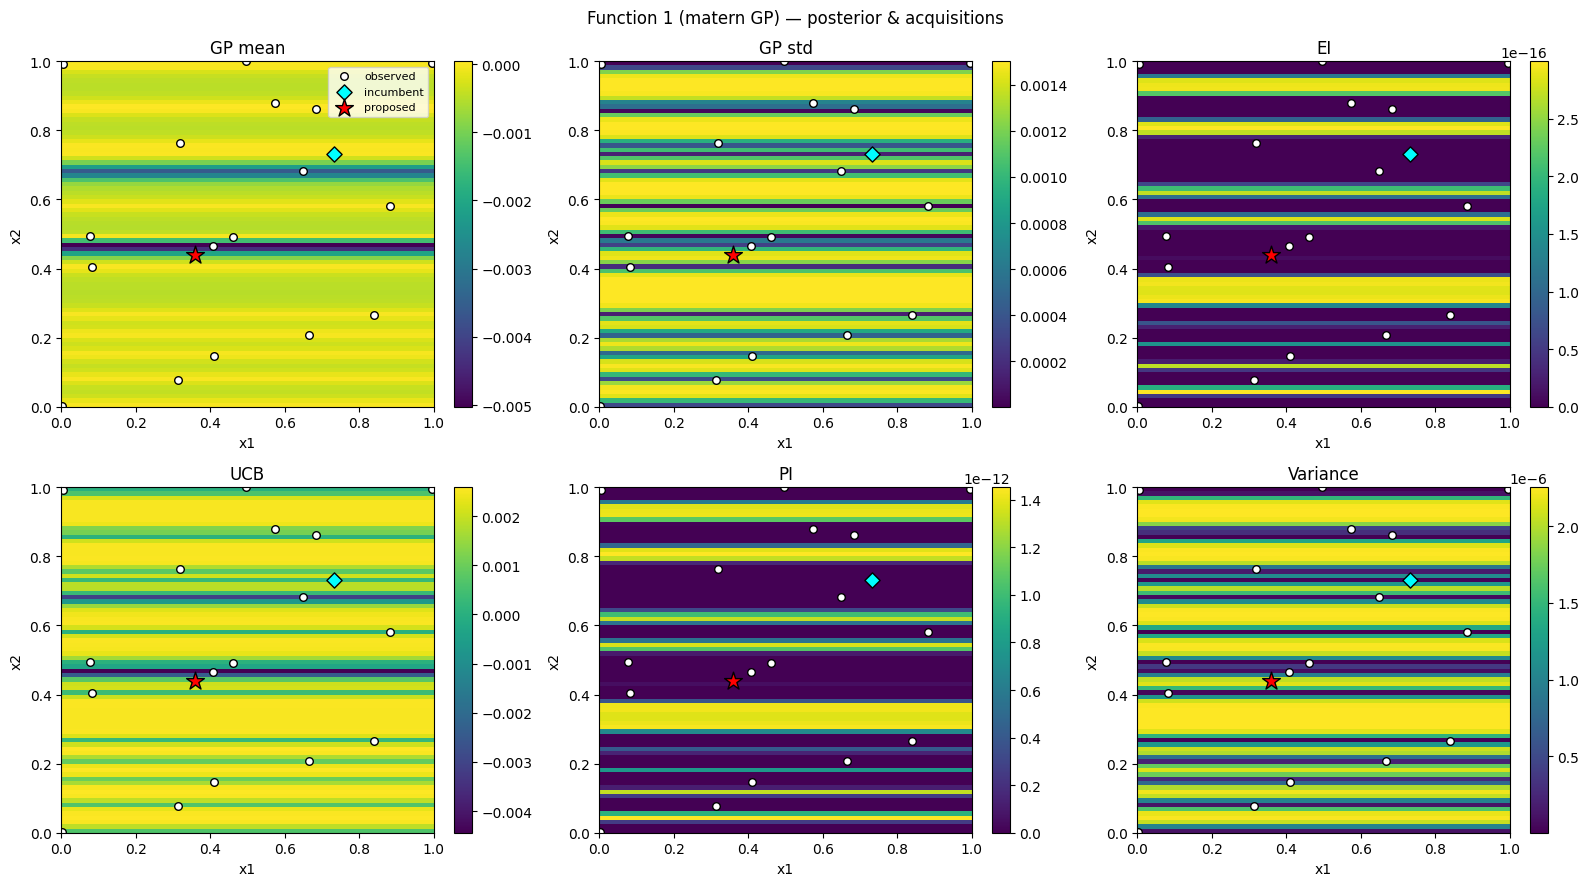

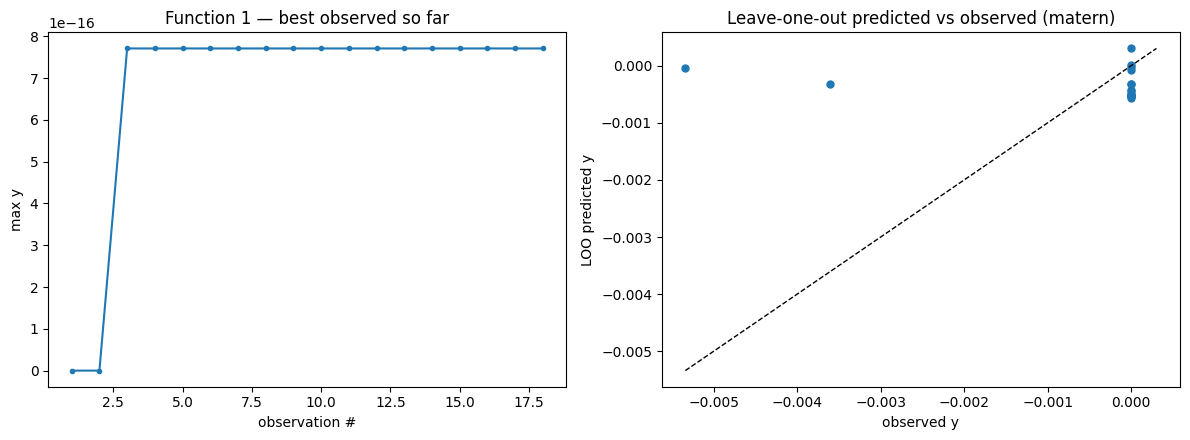

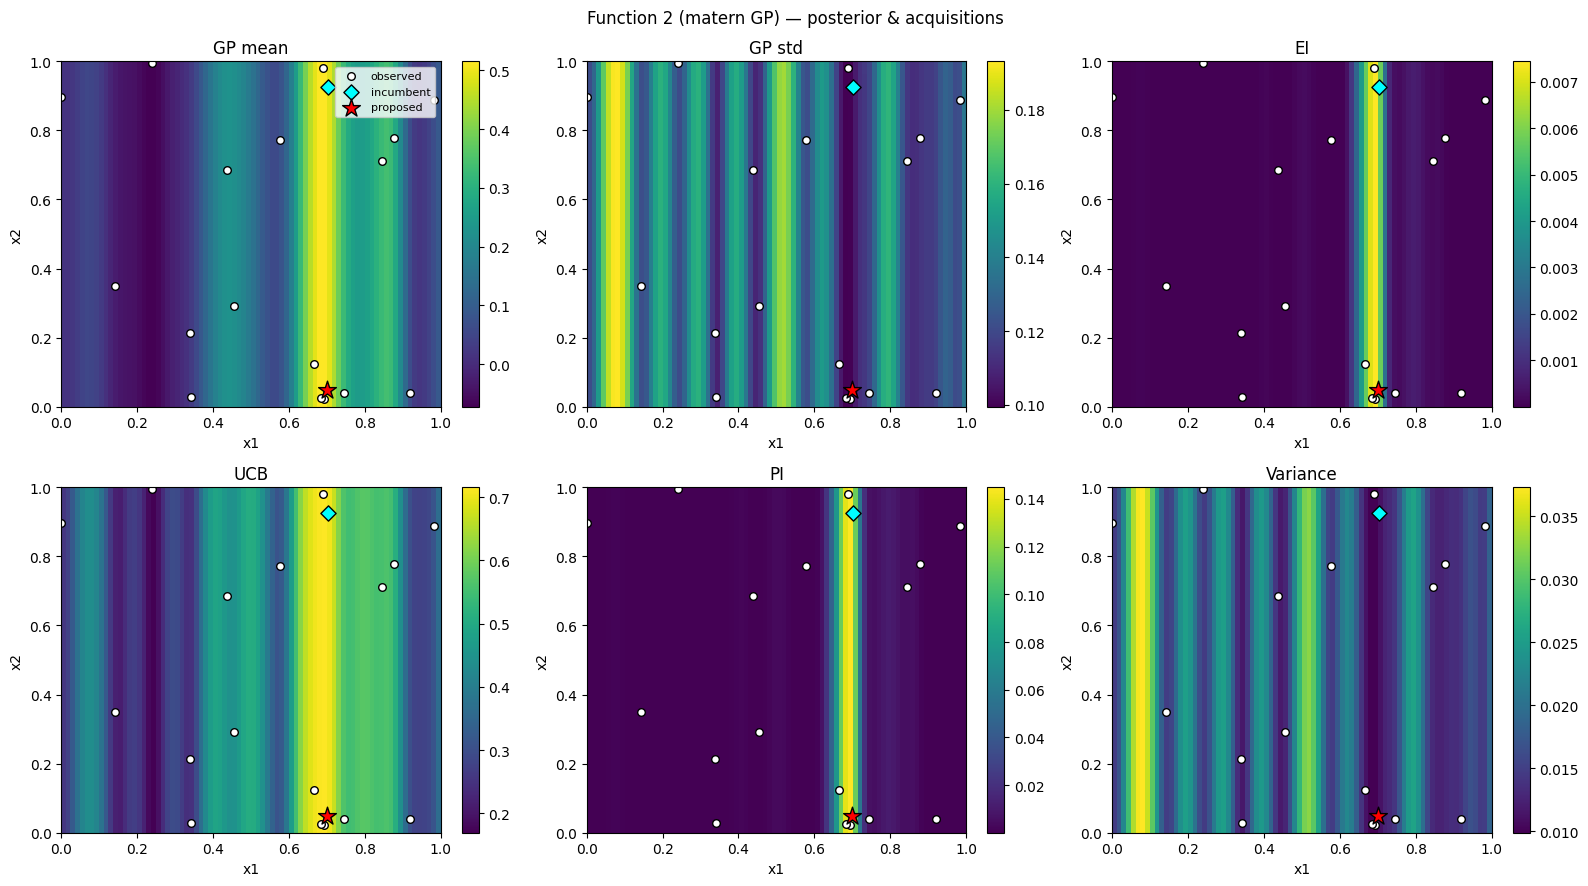

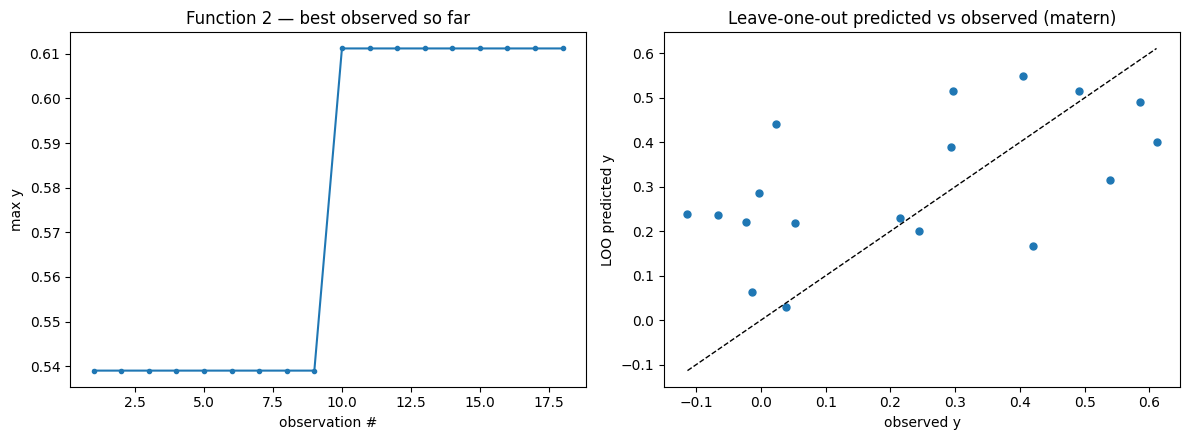

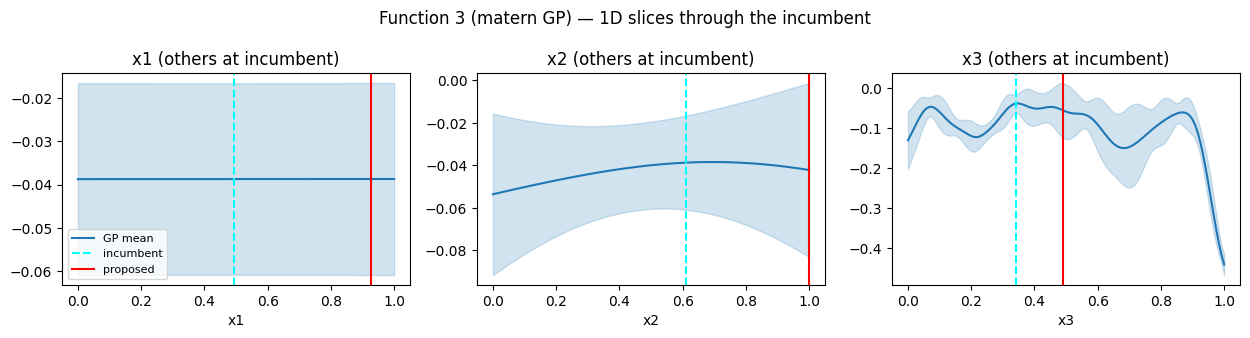

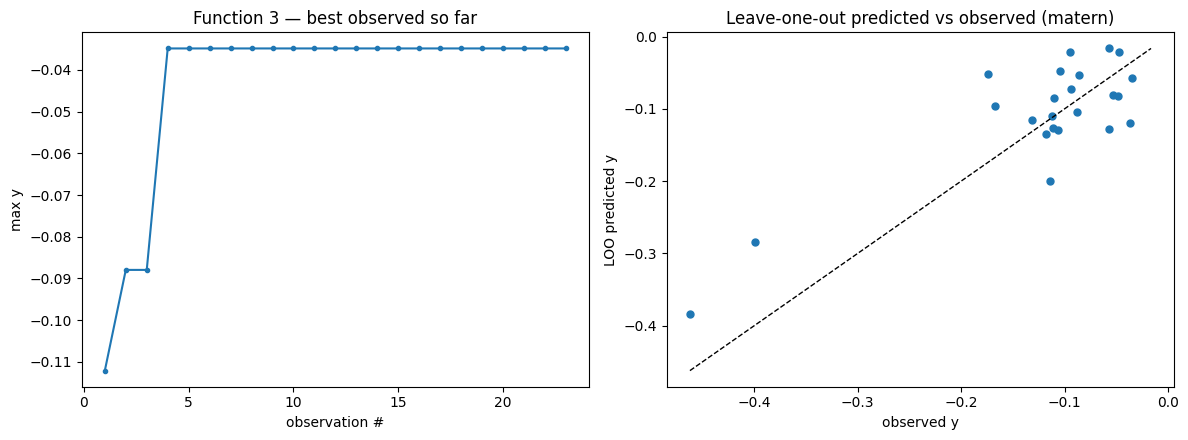

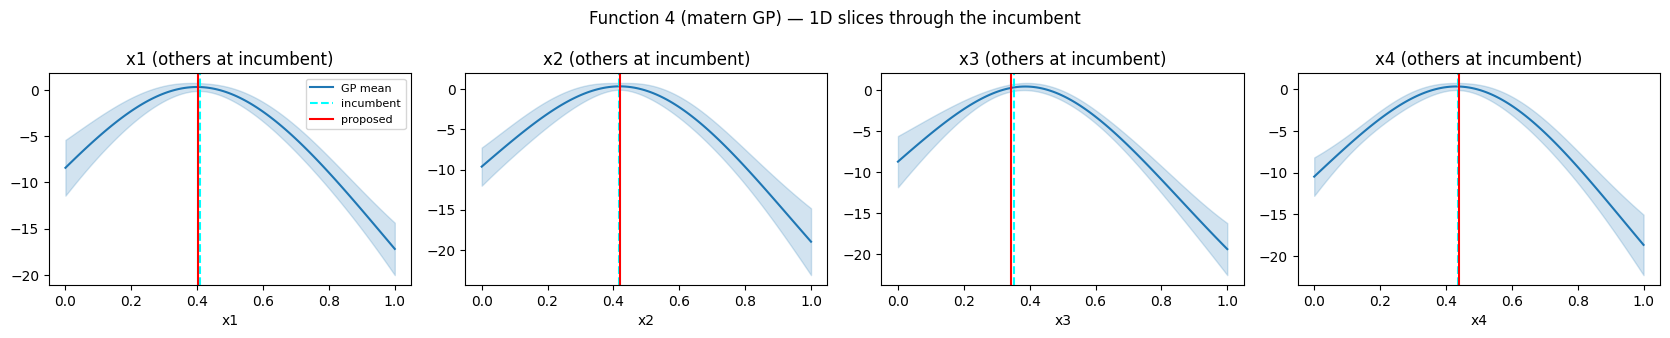

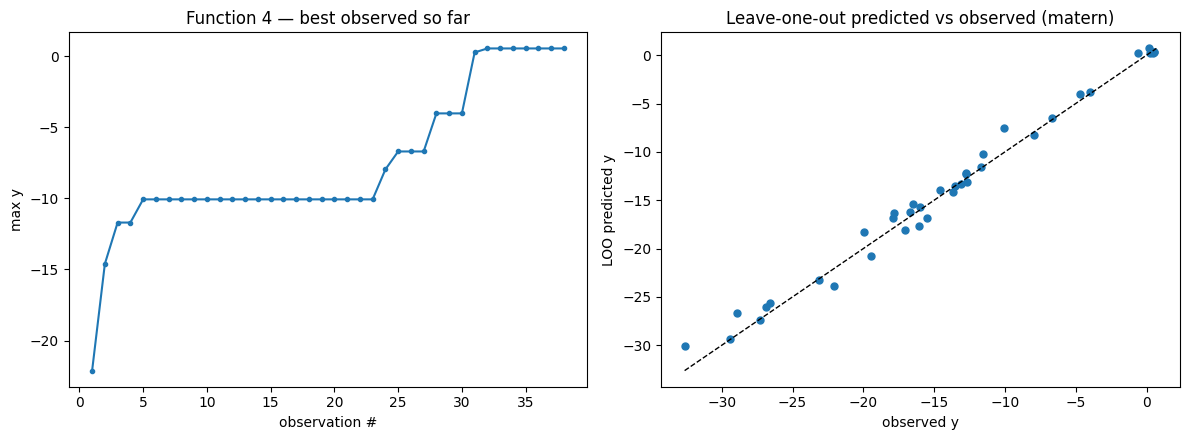

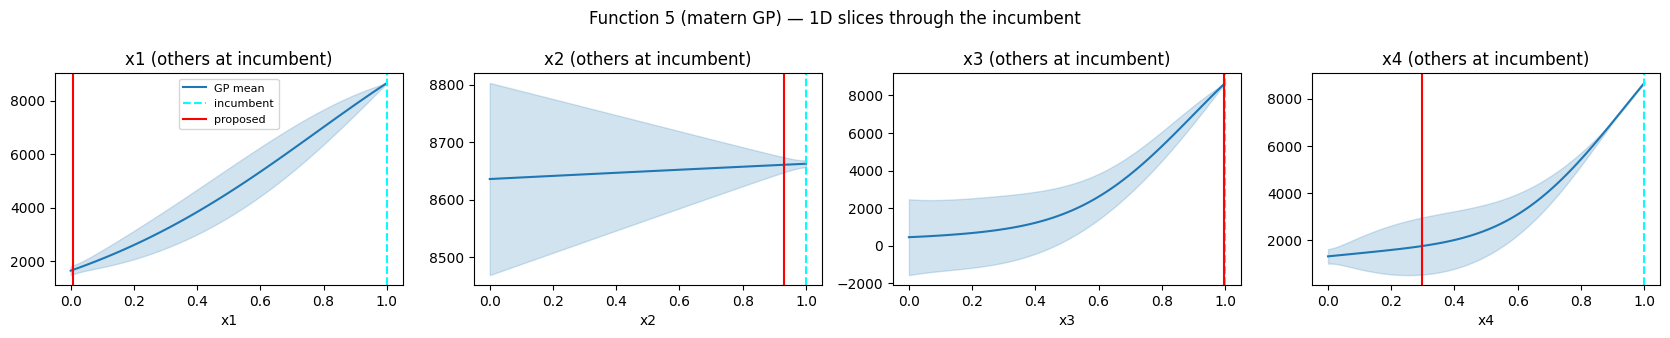

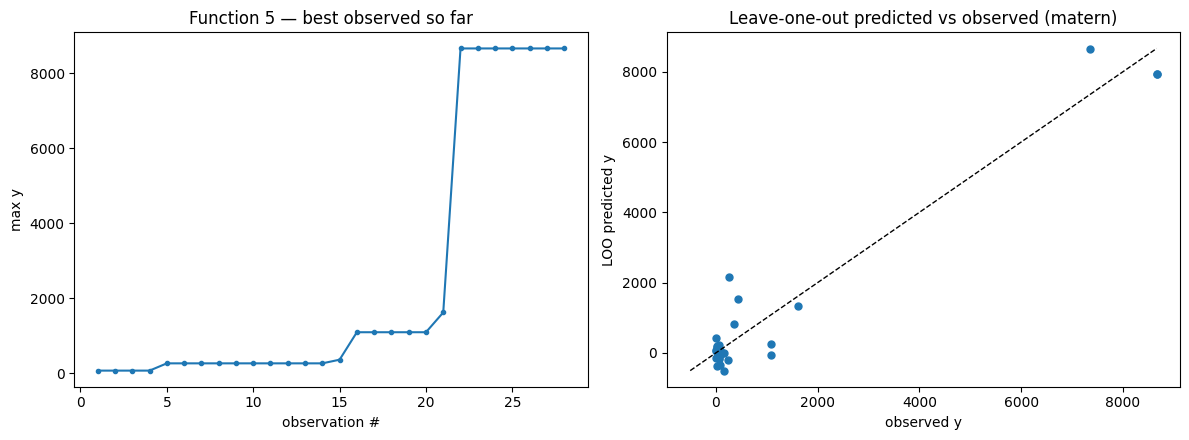

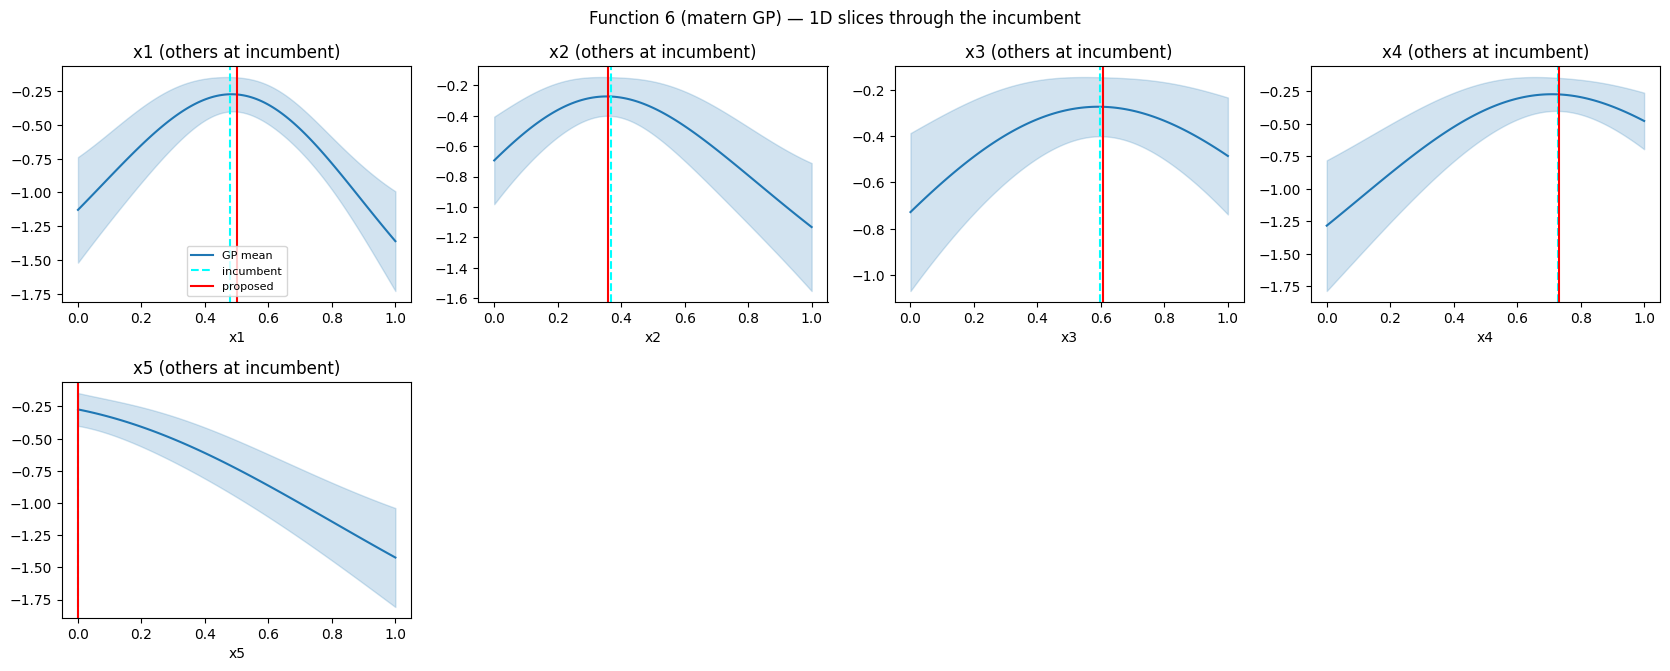

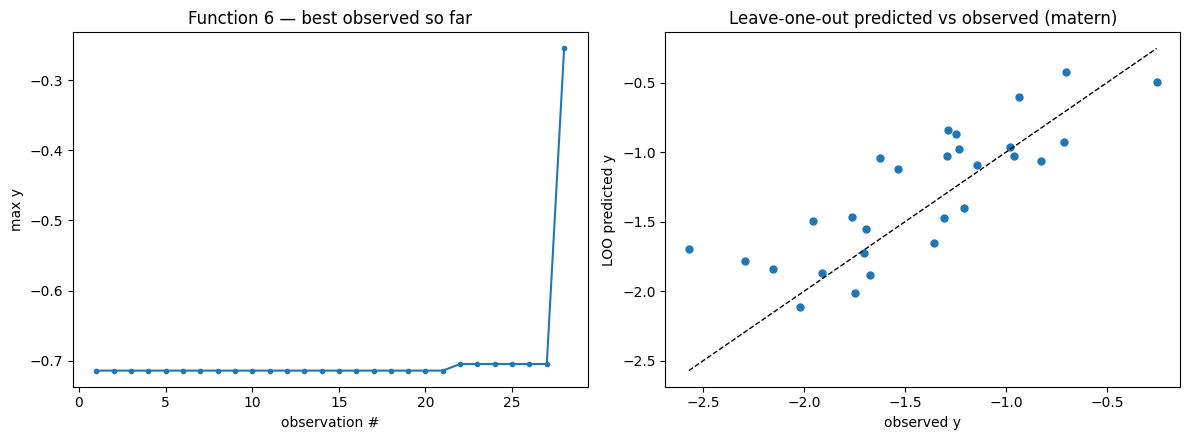

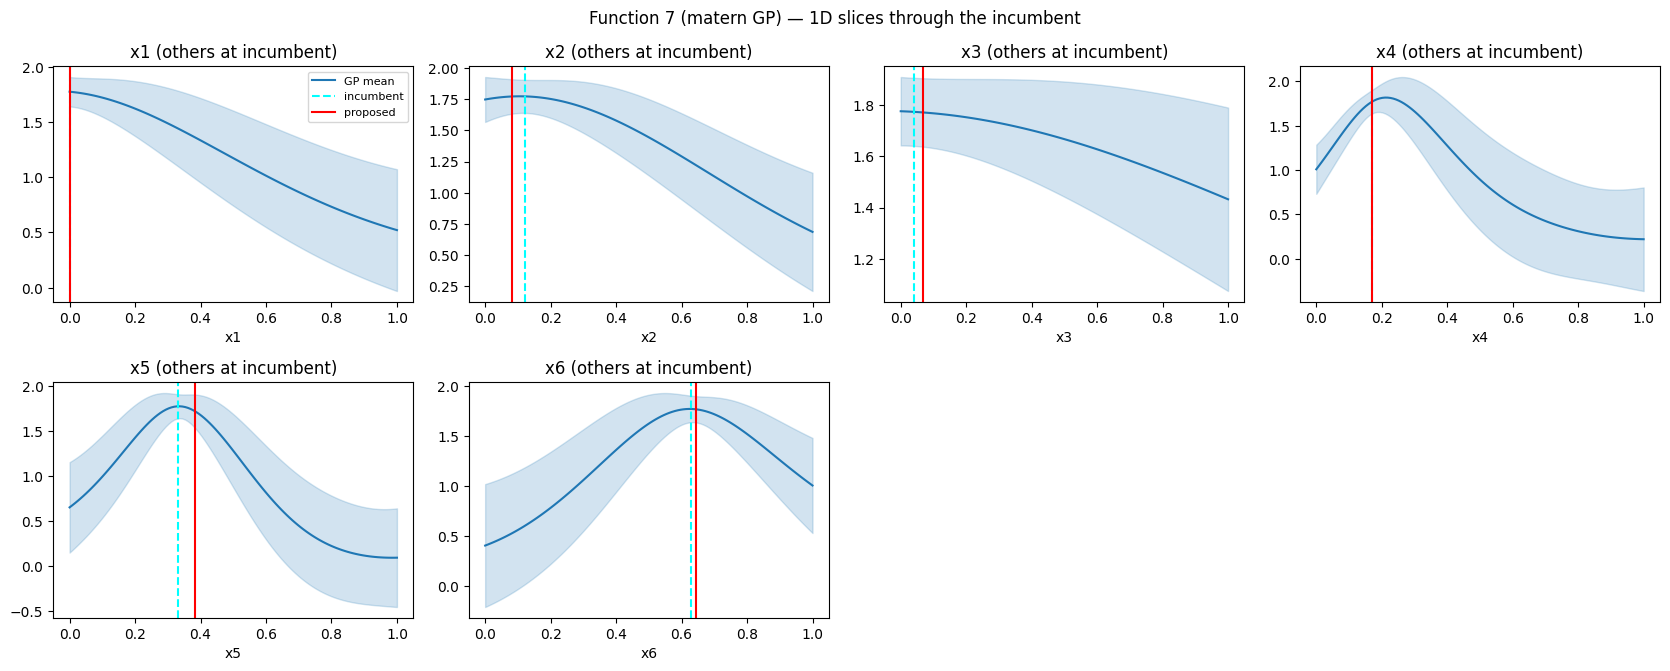

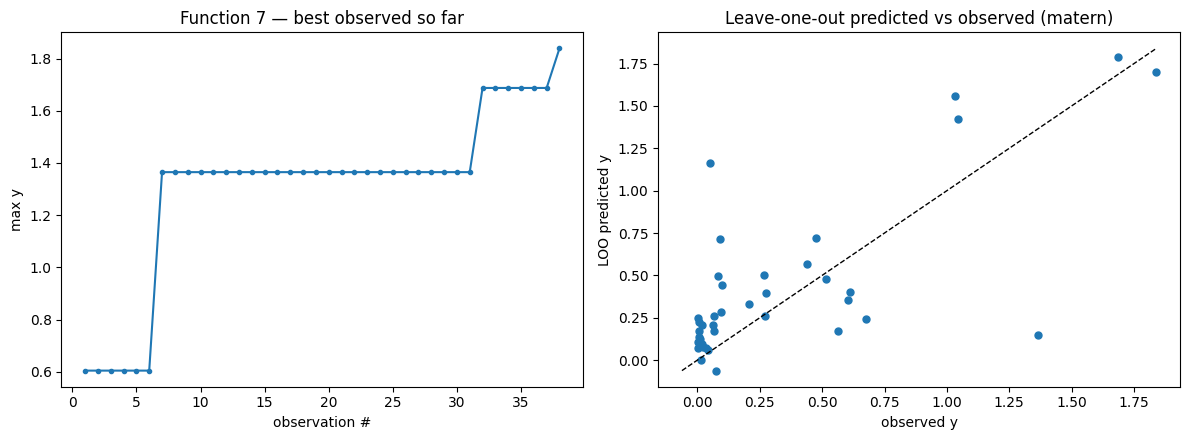

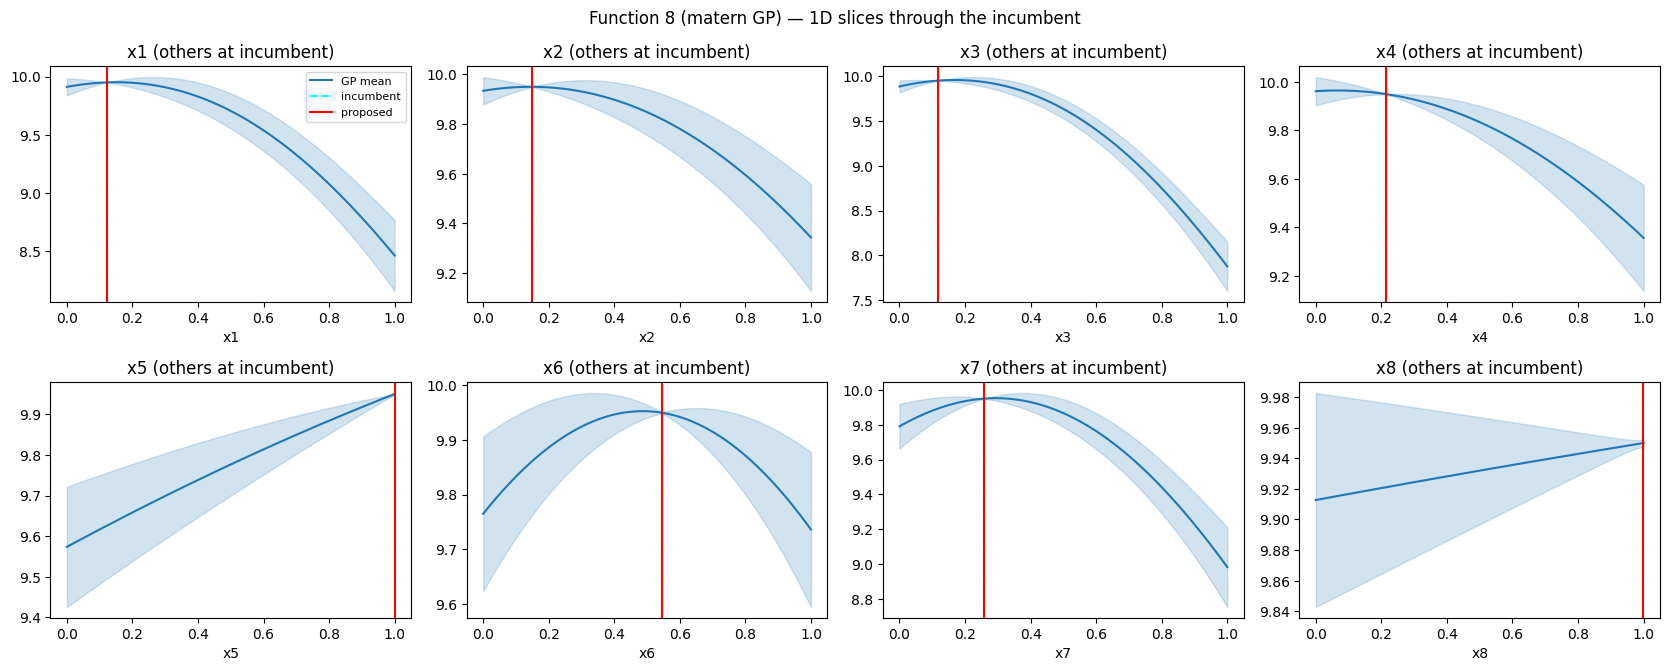

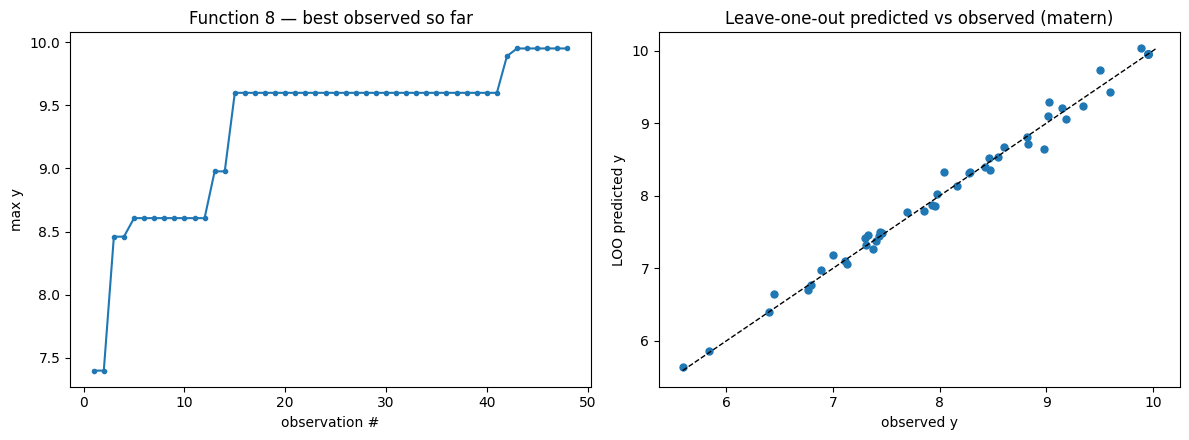

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r.get("model") or bo.fit(fid)
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.360000-0.440000
f2:  0.699851-0.047138
f3:  0.925193-0.999999-0.491149
f4:  0.402947-0.419269-0.342834-0.440701
f5:  0.007603-0.930329-0.997611-0.296371
f6:  0.501950-0.357328-0.606603-0.733165-0.000000
f7:  0.000000-0.080670-0.069240-0.170319-0.382669-0.645238
f8:  0.121753-0.148827-0.117863-0.213194-0.999999-0.545166-0.258453-0.997690


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite an already-written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week09.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 9 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: -0.0007828871397078733,
#     2: 0.6823483366445214,
#     3: -0.0633760150926809,
#     4: 0.30908989010461996,
#     5: 1132.5353726623239,
#     6: -0.2638890637649581,
#     7: 1.719912712096705,
#     8: 9.9499278285255,
# }
#
# TWO NEW BESTS:
#   f2 0.682 vs 0.611 (+0.071) - FIRST f2 improvement in 9 weeks. Conservative AEI near-incumbent.
#   f8 9.9499278 (marginal) - third consecutive MES nudge.
#
# The rest:
#   f1 -0.00078 at (0.36, 0.44): stronger than W8's centre probe (-1.4e-6), weaker than
#      W7's (0.41,0.47) reading (-0.0053). We've now bracketed the hot spot along this line.
#      (0.41, 0.47) remains the strongest reading -> next probe PERPENDICULAR to the line.
#   f3 -0.063 vs -0.035 (miss)
#   f4 0.309 vs 0.540 - ALARM. The clamped +/-0.01 refine cost 0.23, WORSE than W8's
#      +/-0.02 (which cost 0.03). Distance doesn't predict loss -> f4 is likely NOISY or
#      razor-rugged. The 0.5401 'peak' may be partly luck. Re-submit the EXACT W2 coords
#      NOW (W10), not at the W12 rehearsal - if it doesn't reproduce, we need weeks to react.
#   f5 1133 (another region mapped; corner still king)
#   f6 -0.264 vs -0.254 - near-reproduced; the new basin is locally flat (good sign for the lock).
#   f7 1.720 vs 1.839 - the tried direction slopes down; 1.839 stands.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
